# MESSAGEix-Pakistan 
### Baseline Model
In this notebook, we are reading data and building baseline scenerio.

<img src="https://wit.lums.edu.pk/sites/default/files/inline-images/WIT_Banner.jpg" alt="Girl in a jacket" width="850" height="250">

In [16]:
# fundamental libraries
import os
import pandas as pd
import numpy as np
import ixmp
import message_ix
from message_ix import log


# for reporting and visualization
from modelFiles.plotter import plotter_MSG

# script functions
from modelFiles.utils import *
from modelFiles.adjust_capacity import adjust_capacity
from modelFiles.national_ev_policy import ev_shares
from modelFiles.adjust_transport import adjust_transport
from modelFiles.elec_gen_shares import generation_shares
from modelFiles.add_fuel_prices import add_fuel_prices
from modelFiles.update_calibration import model_calibrate
from modelFiles.adjust_activity import adjust_activity


# autoreload modules when changes are applied to them
%load_ext autoreload 
%autoreload all
%reload_ext autoreload
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [17]:
# saving current working directory path for later repeated use
cwd_path = os.getcwd()

Create scenario

In [18]:
# creating ixmp platform object
new_mp = ixmp.Platform("committed 5.0")

# creating a new, empty scenario object
scenario = message_ix.Scenario(
    new_mp, model="COMMITTED", scenario="baseline", version="new"
)

Read Data

In [19]:
# loading data (sets & parameters) into our model - latest data file is MESSAGEix_Pakistan_SSP2_V2.2_Baseline.xlsx
data_path = "./modelData/MESSAGEix_Pakistan_SSP2_V2.2_Baseline.xlsx"
scenario.read_excel(data_path, add_units=True, commit_steps=False, init_items=True,)

In [20]:
scenario = scenario.clone(scenario.model, "baseline", keep_solution=False, shift_first_model_year=2025)

In [21]:
# keep the model's temporal scope till 2070 only
modify_last_year(scenario, 2070)

In [22]:
tecs = ["loil_imp", "oil_imp", "coal_imp"]
insert_history(scenario, 2020, tecs)


In [23]:
# capacity
# adjust_capacity(scenario)

In [24]:
# adjust_activity(scenario)

In [25]:
insert_solar_distribution(scenario)

In [26]:
adjust_transport(scenario)

In [27]:
# list of technologies outputing on the demand level
# tec_list = list(set((scenario.par(
#                 'output', {'level': 'useful',
#                         'commodity': 'i_therm'}))['technology']))

In [28]:
# print(tec_list)

In [29]:
# scenario.remove_solution()

In [30]:
# scenario.check_out()

In [31]:
ev_shares(scenario)

In [32]:
generation_shares(scenario)

In [33]:
# model_calibrate(scenario, nodeNames=["R12_PAK"], replace_negative=False)

##### Solve the Model

In [34]:
log.info(f"version number before commit(): {scenario.version}")

# commit the model structure and input data (sets and parameters)
scenario.commit(comment="Add all data from excel file to scenario")
scenario.set_as_default()

# exporting the built model (Scenario) to GAMS with an optional case name
caseName = scenario.model + '__' + scenario.scenario + '__v' + str(scenario.version)

# solve model
scenario.solve(case=caseName)

scenario.var("OBJ")["lvl"]

21724.22265625

In [35]:
# scenario.remove_solution()

In [36]:
# df = scenario.par('initial_activity_lo',filters= {'technology':'oil_imp'})

In [37]:
# df['value'] = 0

In [38]:
# with scenario.transact(''):
    # scenario.add_par('initial_activity_lo',df)

##### Reporting Results

In [39]:
# from modelFiles.report.iamc_report_hackathon import report
# from datetime import datetime
# import time
# timestamp = f"{str(datetime.now().strftime('%Y-%m-%d--%H-%M'))}"
# start = time.time()
# df, path_name= report(mp=new_mp, scen=scenario, out_dir="reporting_outputs", out_file_timestamp = timestamp, IDEA_format=False)
# end = time.time()

##### Plotting Results

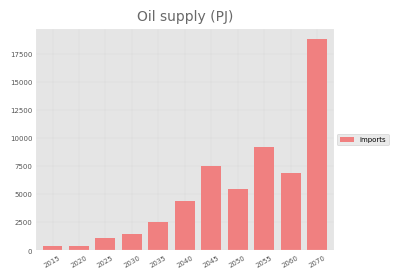

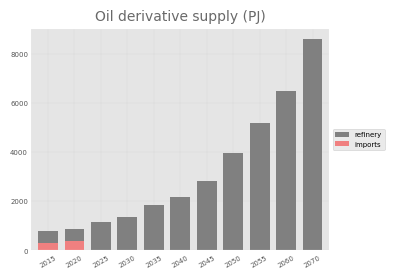

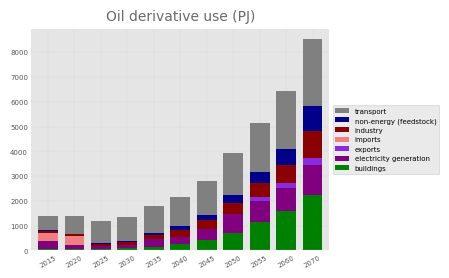

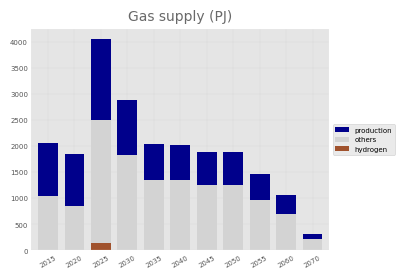

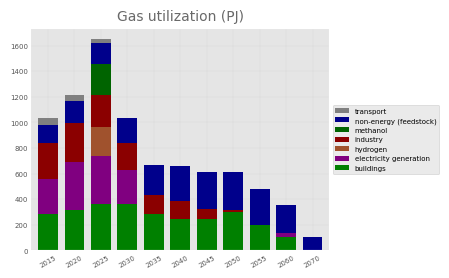

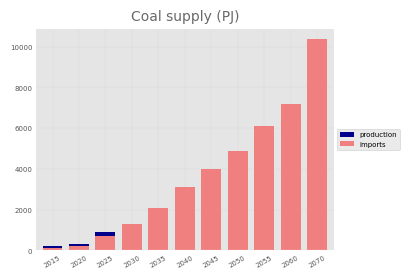

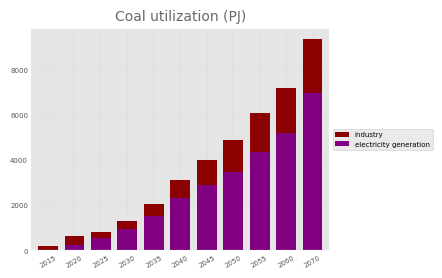

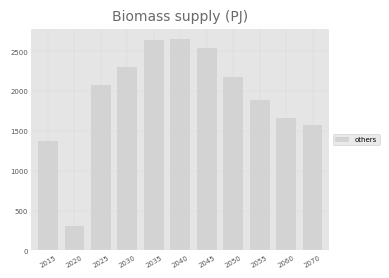

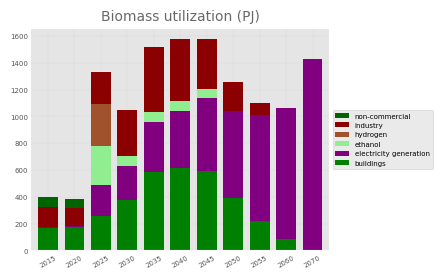

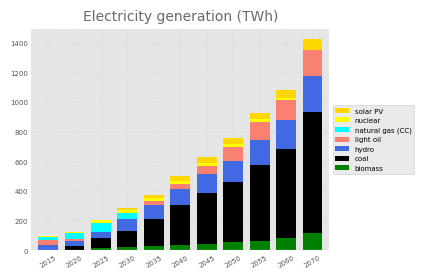

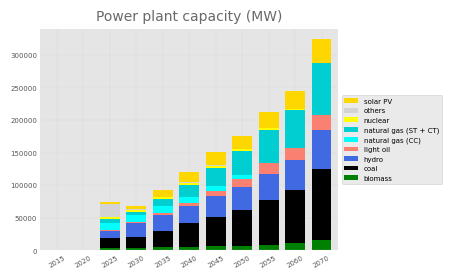

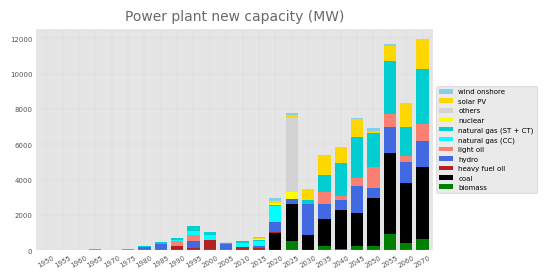

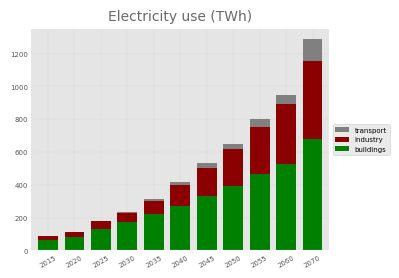

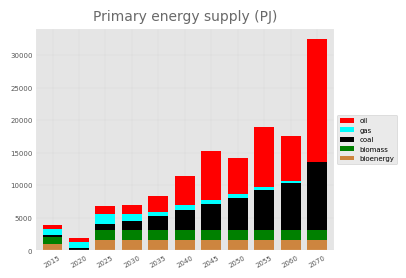

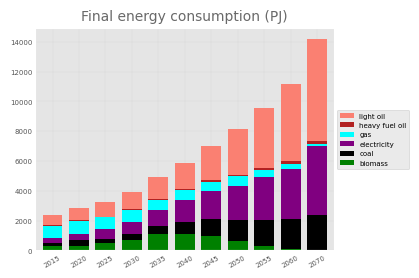

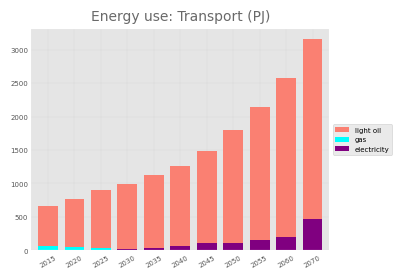

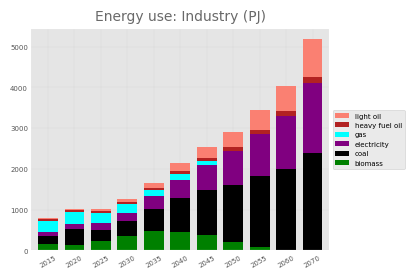

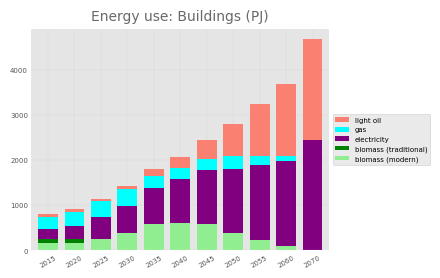

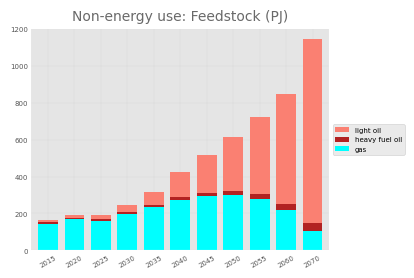

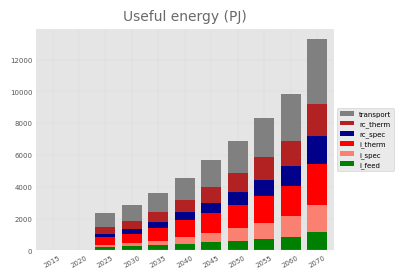

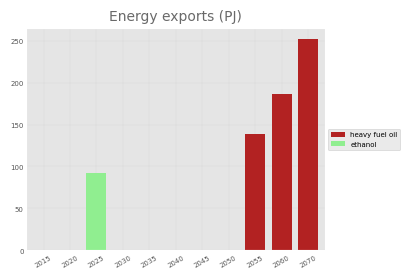

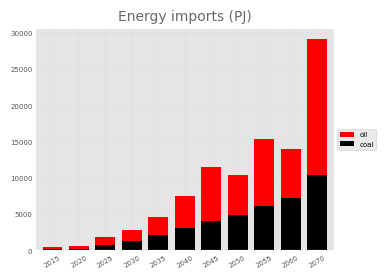

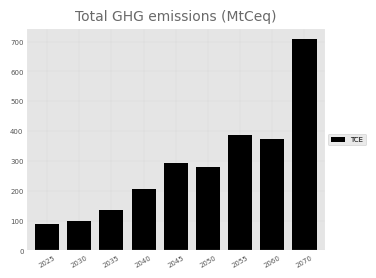

{'Electricity generation (TWh)':          biomass        coal       hydro   light oil  natural gas (CC)  \
 2015    0.556260    0.148044   34.632660   35.362368         22.428041   
 2020    0.711312   27.549324   33.548172   17.195880         36.731689   
 2025   19.350881   66.673793   40.395918    0.000000         55.881463   
 2030   21.089808  112.867770   75.340528    1.499647         40.402589   
 2035   31.169860  181.350586   94.173101   25.828027          0.000000   
 2040   35.672389  270.789779  108.921953   34.874982          0.000000   
 2045   45.033396  339.553537  133.563347   51.859711          0.000000   
 2050   54.455720  404.201405  145.721184   95.505096          0.000000   
 2055   66.185949  509.135091  168.132818  121.896293          0.000000   
 2060   81.386292  605.317413  191.455361  135.743223          0.000000   
 2070  118.987049  812.470186  244.875566  177.534785          0.000000   
 
         nuclear   solar PV  
 2015   4.605132   0.368280  
 2020 

In [49]:
path = os.path.join(cwd_path, "output/plots")
plotter = plotter_MSG(scenario)
plotter.plotter(caseName, nodeloc=["R12_PAK"], path=path, yr_min=2015, yr_max=2070)

In [43]:
# close the connection to the database
new_mp.close_db() 

In [48]:
new_mp.open_db()